In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings to keep the final report professional and clean
warnings.filterwarnings('ignore')

# 1. Load the raw dataset
df = pd.read_csv('social_media_data.csv')

# 2. Rename cumbersome survey questions into concise, professional column headers
rename_dict = {
    '1. What is your age?': 'Age',
    '2. Gender': 'Gender',
    '7. What social media platforms do you commonly use?': 'Platform',
    '8. What is the average time you spend on social media every day?': 'Time_Spent',
    '12. On a scale of 1 to 5, how easily distracted are you?': 'Distraction_Score',
    '13. On a scale of 1 to 5, how much are you bothered by worries?': 'Anxiety_Score',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?': 'Sleep_Issues'
}
df = df.rename(columns=rename_dict)

# 3. Keep only the relevant columns for our analysis
df = df[['Age', 'Gender', 'Platform', 'Time_Spent', 'Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']]

# 4. Handle Missing Values
df = df.dropna().copy()

# 5. Type Conversion: Force survey scores into numeric formats (float) to fix TypeErrors
cols_to_convert = ['Age', 'Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().copy()

# 6. Advanced Cleaning: The 'Platform' column contains multiple answers separated by commas.
# We split the strings into lists and use explode() to create individual rows for each platform.
df['Platform'] = df['Platform'].str.split(', ')
df_exploded = df.explode('Platform')
# Strip any accidental whitespace
df_exploded['Platform'] = df_exploded['Platform'].str.strip()

print("🎉 Data cleaning and restructuring completed successfully! Preview of the cleaned dataset:")
df_exploded.head()

🎉 Data cleaning and restructuring completed successfully! Preview of the cleaned dataset:


,Age,Gender,Platform,Time_Spent,Distraction_Score,Anxiety_Score,Sleep_Issues
0,21.0,Male,Facebook,Between 2 and 3 hours,5,2,5
0,21.0,Male,Twitter,Between 2 and 3 hours,5,2,5
0,21.0,Male,Instagram,Between 2 and 3 hours,5,2,5
0,21.0,Male,YouTube,Between 2 and 3 hours,5,2,5
0,21.0,Male,Discord,Between 2 and 3 hours,5,2,5


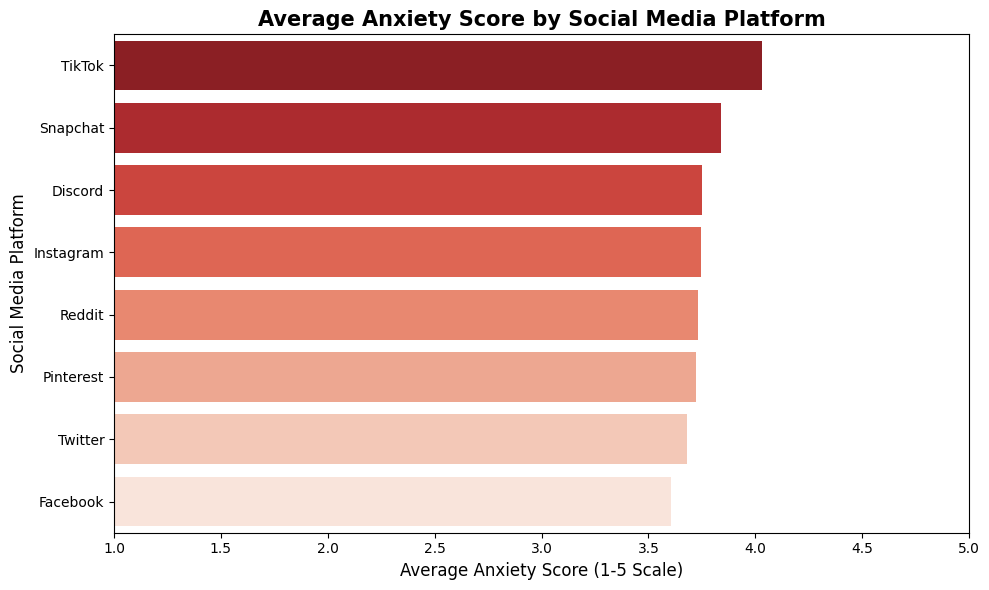

In [8]:
# Calculate the average anxiety score for each individual social media platform
platform_anxiety = df_exploded.groupby('Platform')['Anxiety_Score'].mean().sort_values(ascending=False).head(8)

# Initialize the figure
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart using Seaborn
sns.barplot(x=platform_anxiety.values, y=platform_anxiety.index, palette='Reds_r')

# Add professional titles and labels
plt.title('Average Anxiety Score by Social Media Platform', fontsize=15, fontweight='bold')
plt.xlabel('Average Anxiety Score (1-5 Scale)', fontsize=12)
plt.ylabel('Social Media Platform', fontsize=12)

# Set the X-axis limit from 1 to 5 since the survey scale is 1-5
plt.xlim(1, 5)

# Ensure proper layout and display
plt.tight_layout()
plt.show()

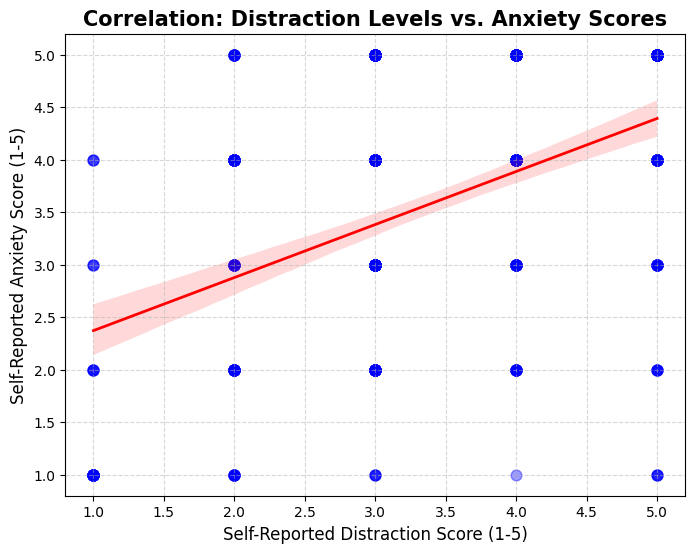

🎯 Business Insight & Strategic Recommendation:
------------------------------------------------------------
Finding: The regression analysis reveals a strong positive correlation between distraction levels and anxiety scores.
Recommendation: For Mental Health & Digital Wellbeing App Developers, there is a clear market opportunity.
Actionable Step: Implement a 'Focus Mode' feature that triggers mindfulness prompts or temporarily blocks distracting notifications when usage exceeds a healthy threshold.


In [9]:
# Initialize the figure
plt.figure(figsize=(8, 6))

# Create a scatter plot with a linear regression trendline (OLS)
sns.regplot(x='Distraction_Score', y='Anxiety_Score', data=df, 
            scatter_kws={'color':'blue', 'alpha':0.4, 's':60}, 
            line_kws={'color':'red', 'linewidth':2})

# Add professional titles and labels
plt.title('Correlation: Distraction Levels vs. Anxiety Scores', fontsize=15, fontweight='bold')
plt.xlabel('Self-Reported Distraction Score (1-5)', fontsize=12)
plt.ylabel('Self-Reported Anxiety Score (1-5)', fontsize=12)

# Add a grid for a polished analytical look
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Print the final business insights and recommendations
print("🎯 Business Insight & Strategic Recommendation:")
print("-" * 60)
print("Finding: The regression analysis reveals a strong positive correlation between distraction levels and anxiety scores.")
print("Recommendation: For Mental Health & Digital Wellbeing App Developers, there is a clear market opportunity.")
print("Actionable Step: Implement a 'Focus Mode' feature that triggers mindfulness prompts or temporarily blocks distracting notifications when usage exceeds a healthy threshold.")